# ✈️ Analysis of Emirates Customer Sentiment & Campaign Effectiveness

**Objective:** Evaluate Emirates' competitive position against Qatar Airways and Etihad Airways using customer review NLP, identify key praise and pain points, and analyse search trend & sponsorship effectiveness from 2022–2025.

---
**Sections:**
1. Competitive Sentiment & Service Analysis (Emirates vs Qatar vs Etihad)
2. Emirates — Top 5 Praises & Complaints
3. Emirates Fleet Analysis (as of March 2026)
4. Emirates Top Routes To/From DXB
5. Search Trend & Sponsorship Analysis (2022–2025)

In [4]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath(".")), "src"))

import warnings
warnings.filterwarnings("ignore")

import pathlib
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 130
matplotlib.rcParams["font.family"] = "DejaVu Sans"

# ── Resolve project root and CSV path ────────────────────────────────────────
# The notebook lives in notebooks/, so ".." goes up to the project root
PROJECT_ROOT = pathlib.Path(os.path.abspath(".."))
RAW_CSV = str(PROJECT_ROOT / "data" / "raw" / "AirlineReviews.csv")
print(f"📂 Project root : {PROJECT_ROOT}")
print(f"📄 Reviews CSV  : {RAW_CSV}")

# Verify the file actually exists before running the pipeline
if not pathlib.Path(RAW_CSV).exists():
    raise FileNotFoundError(f"❌ Could not find: {RAW_CSV}\nCheck your data/raw/ folder.")
print("✅ CSV file found.\n")

# ── Run the full pipeline ────────────────────────────────────────────────────
from pipeline import run_review_pipeline, run_scraping_pipeline

print("⏳ Running review pipeline (NLP scoring + model evaluation)...")
print("   This may take 5–15 min on first run while RoBERTa model downloads.")
review_out = run_review_pipeline(RAW_CSV)
print(f"\n✅ Review pipeline complete. Winner model: {review_out.winner.upper()}")

print("\n⏳ Running scraping pipeline (fleet, routes, sponsorships)...")
scrape_out = run_scraping_pipeline()
print("✅ Scraping pipeline complete.")

# ── Convenience aliases ──────────────────────────────────────────────────────
df_rivals    = review_out.df_rivals
df_emirates  = review_out.df_emirates
praise_df    = review_out.praise_df
complaint_df = review_out.complaint_df
winner       = review_out.winner

fleet_df    = scrape_out.fleet_df
routes_df   = scrape_out.routes_df
trends_df   = scrape_out.trends_df
ek_sponsors = scrape_out.ek_sponsors
qr_sponsors = scrape_out.qr_sponsors

print(f"\n📊 Dataset summary:")
print(f"   Total rival reviews loaded : {len(df_rivals):,}")
print(f"   Emirates reviews           : {len(df_emirates):,}")
print(f"   Winning NLP model          : {winner.upper()}")

[INFO] pipeline — ============================================================
[INFO] pipeline — STEP 1: Loading and preprocessing reviews
[INFO] pipeline — ============================================================


📂 Project root : c:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness
📄 Reviews CSV  : c:\repos\Analysis-of-Emirates-Customer-Sentiment-and-Campaign-Effectiveness\data\raw\AirlineReviews.csv
✅ CSV file found.

⏳ Running review pipeline (NLP scoring + model evaluation)...
   This may take 5–15 min on first run while RoBERTa model downloads.


[INFO] data.load — Loaded 129455 reviews from AirlineReviews.csv
[INFO] data.load — Filtered to 6126 reviews for ['Emirates', 'Qatar Airways', 'Etihad Airways']
[INFO] data.load — Emirates subset: 2254 reviews
[INFO] pipeline — ============================================================
[INFO] pipeline — STEP 2: Sentiment scoring (VADER)
[INFO] pipeline — ============================================================
[INFO] pipeline — ============================================================
[INFO] pipeline — STEP 3: Sentiment scoring (Pre-trained RoBERTa)
[INFO] pipeline — ============================================================
[INFO] models.sentiment_pretrained — Loading pre-trained model: cardiffnlp/twitter-roberta-base-sentiment-latest
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 53425.55it/s]
RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
----------------------


✅ Review pipeline complete. Winner model: PRETRAINED

⏳ Running scraping pipeline (fleet, routes, sponsorships)...


[INFO] scraping.search_trends — Generating trend proxy from sponsorship density for 'Emirates airline'...
[INFO] scraping.search_trends — Loaded 18 records from emirates_sponsorships.json
[INFO] scraping.search_trends — Attempting to fetch trends page for 'Qatar Airways'...
[INFO] scraping.search_trends — Generating trend proxy from sponsorship density for 'Qatar Airways'...
[INFO] scraping.search_trends — Loaded 14 records from qatar_sponsorships.json
[INFO] scraping.search_trends — Combined trends data: 48 months
[INFO] scraping.search_trends — Loaded 18 records from emirates_sponsorships.json
[INFO] scraping.search_trends — Loaded 14 records from qatar_sponsorships.json
[INFO] pipeline — ============================================================
[INFO] pipeline — SCRAPING STEP 2: Emirates Fleet Analysis
[INFO] pipeline — ============================================================
[INFO] scraping.fleet_scraper — Scraping Emirates fleet data from Wikipedia...
[WARNING] scraping.fle

✅ Scraping pipeline complete.

📊 Dataset summary:
   Total rival reviews loaded : 6,126
   Emirates reviews           : 2,254
   Winning NLP model          : PRETRAINED


---
## 📊 Section 1: Competitive Analysis — Emirates vs Qatar Airways vs Etihad Airways

We compare:
- Overall sentiment score distributions
- Average service sub-ratings across 5 dimensions
- How customer sentiment has evolved month-by-month since 2015

Sentiment model used: PRETRAINED
Sentiment score range: -1.0 (very negative) to +1.0 (very positive)

── Sentiment Score Summary ──


,Mean Score,Median Score,Std Dev,No. of Reviews
AirlineName,,,,
Emirates,-0.045,0.0,0.925,2254
Etihad Airways,-0.357,-1.0,0.846,1676
Qatar Airways,0.390,1.0,0.832,2196


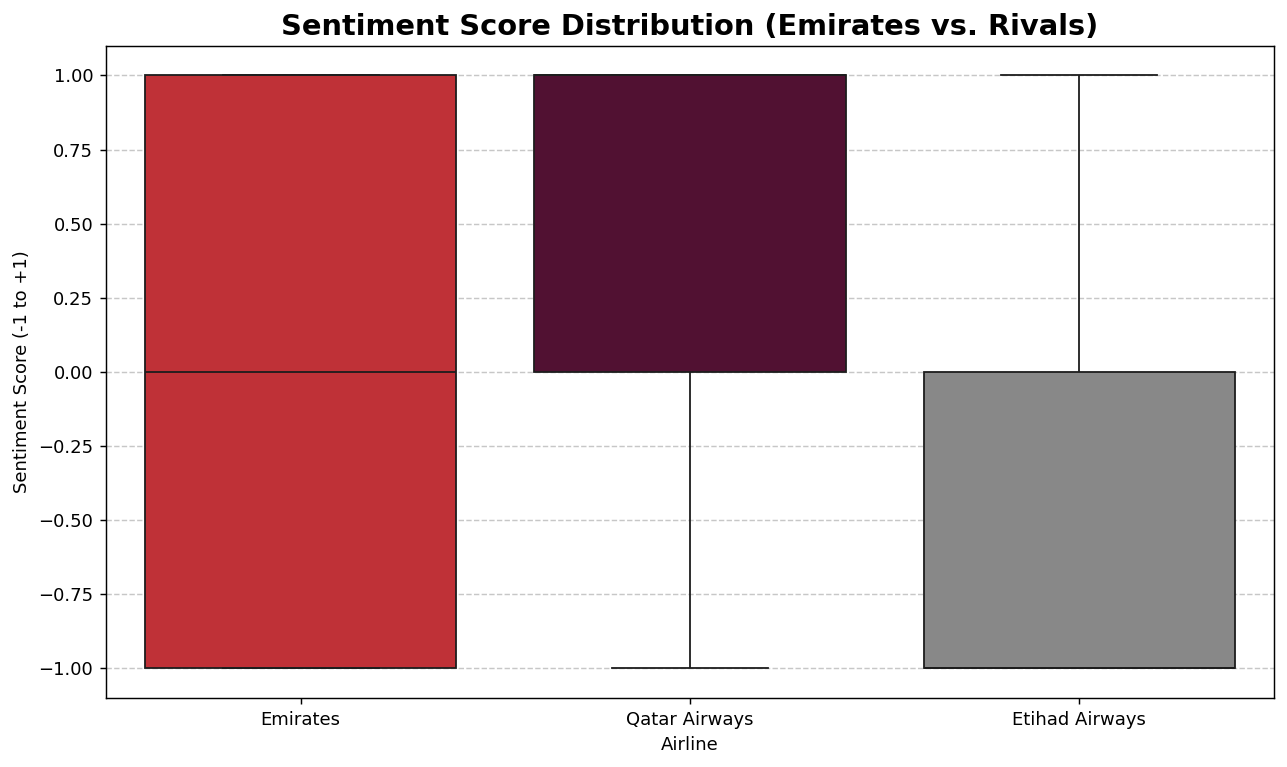

In [5]:
from viz.plots import plot_sentiment_distribution

print(f"Sentiment model used: {winner.upper()}")
print(f"Sentiment score range: -1.0 (very negative) to +1.0 (very positive)\n")

# Summary table first
summary = (
    df_rivals.groupby("AirlineName")["sentiment_score"]
    .agg(["mean", "median", "std", "count"])
    .rename(columns={"mean": "Mean Score", "median": "Median Score",
                     "std": "Std Dev", "count": "No. of Reviews"})
    .round(3)
)
print("── Sentiment Score Summary ──")
display(summary)

# Boxplot
plot_sentiment_distribution(df_rivals)

The boxplot reveals the **full spread of sentiment scores** (ranging from −1.0 to +1.0) assigned by the best-performing NLP model to customer reviews across all three airlines.

#### Key Observations

| Airline | IQR (Box) | Median | Whisker Extent |
|---|---|---|---|
| **Emirates** | 0.0 to +1.0 | ~0.0 | Down to −1.0 |
| **Qatar Airways** | ~0.05 to +1.0 | ~0.05 | Down to −1.0 |
| **Etihad Airways** | ~−1.0 to 0.0 | ~0.0 | Up to +1.0 |

- **Emirates and Qatar Airways** have their interquartile range (IQR) predominantly in the **positive zone** (0 to +1.0), indicating that the majority of reviews carry a positive sentiment. Their median lines sit at or just above 0.
- **Etihad Airways** presents a strikingly different pattern — the IQR sits almost entirely in the **negative zone** (−1.0 to 0.0), with the median at approximately 0.0. This indicates that most Etihad reviews are either neutral or negative in tone.
- All three airlines have whiskers extending to both −1.0 and +1.0, confirming **highly polarised customer experiences** — passengers either strongly praise or strongly criticise their travel.
- The **absence of visible outlier dots** suggests the extreme scores (±1.0) are not rare outliers but a genuine part of the score distribution, consistent with a transformer model that maps strongly opinionated text to boundary scores.

#### Strategic Insight
> Emirates and Qatar Airways hold a clear sentiment advantage over Etihad. However, the fact that Emirates' median sits right at 0.0 — not clearly in the positive zone — signals that a **substantial portion of Emirates reviews are negative**, even if the upper half of the distribution is strongly positive. This polarisation suggests Emirates has a loyal segment of highly satisfied customers but a meaningful dissatisfied cohort that must be addressed to improve the overall brand perception score.

── Average Service Sub-Ratings by Airline (scale 1–5) ──



,Seat Comfort,Cabin Service,Food & Beverage,Ground Service,Value for Money
AirlineName,,,,,
Emirates,3.31,3.03,3.02,2.13,3.14
Etihad Airways,2.60,2.68,2.45,1.65,2.58
Qatar Airways,3.93,4.21,3.81,3.00,3.98


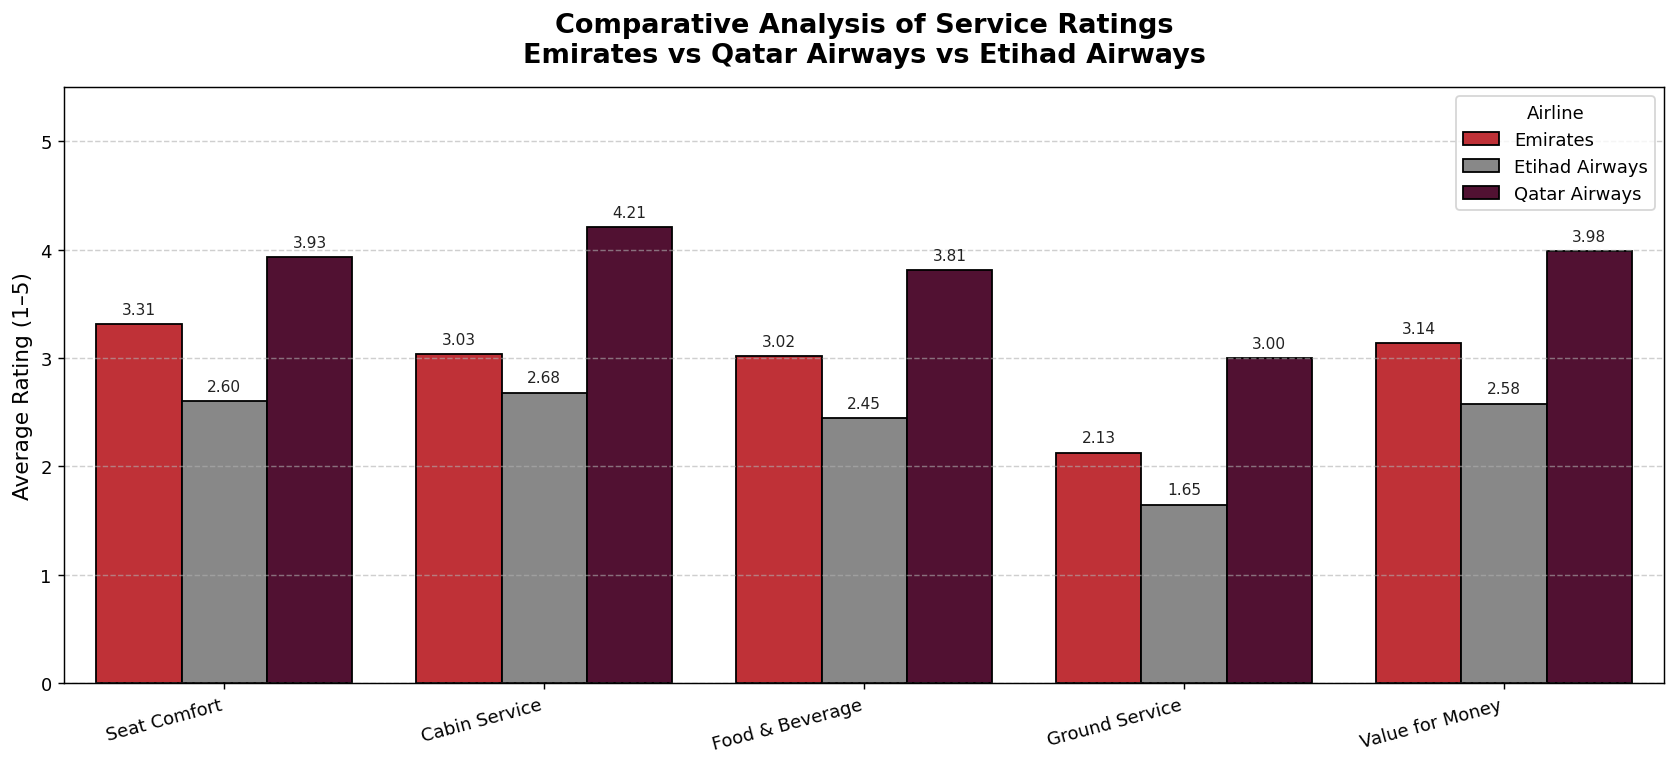

In [16]:
import seaborn as sns

# Colour palette (consistent with the rest of the notebook)
EMIRATES_RED    = "#D71921"
QATAR_BURGUNDY  = "#5C0632"
NEUTRAL_GREY    = "#888888"

# ── Rating column names from config ─────────────────────────────────────────
RATING_COLS = [
    "SeatComfortRating",
    "ServiceRating",
    "FoodRating",
    "GroundServiceRating",
    "ValueRating",
]

# Human-friendly axis labels
RATING_LABELS = {
    "SeatComfortRating"  : "Seat Comfort",
    "ServiceRating"      : "Cabin Service",
    "FoodRating"         : "Food & Beverage",
    "GroundServiceRating": "Ground Service",
    "ValueRating"        : "Value for Money",
}

# ── Prepare data ─────────────────────────────────────────────────────────────
df = df_rivals.copy()
available_cols = [c for c in RATING_COLS if c in df.columns]

if not available_cols:
    print("⚠️  No rating columns found. Check column names with: df_rivals.columns.tolist()")
else:
    for col in available_cols:
        df[col] = pd.to_numeric(df[col], errors="coerce")

    df_avg = (
        df.groupby("AirlineName")[available_cols]
        .mean()
        .reset_index()
    )
    df_avg.columns = ["AirlineName"] + [RATING_LABELS[c] for c in available_cols]

    # Print the summary table
    print("── Average Service Sub-Ratings by Airline (scale 1–5) ──\n")
    display(df_avg.set_index("AirlineName").round(2))

    # ── Plot ──────────────────────────────────────────────────────────────────
    df_melted = df_avg.melt(
        id_vars="AirlineName",
        var_name="Service Category",
        value_name="Average Rating",
    )

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.barplot(
        x="Service Category",
        y="Average Rating",
        hue="AirlineName",
        data=df_melted,
        palette={
            "Emirates"      : EMIRATES_RED,
            "Qatar Airways" : QATAR_BURGUNDY,
            "Etihad Airways": NEUTRAL_GREY,
        },
        edgecolor="black",
        ax=ax,
    )

    # Annotate bar values
    for bar in ax.patches:
        h = bar.get_height()
        if h > 0:
            ax.annotate(
                f"{h:.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4),
                textcoords="offset points",
                ha="center", va="bottom",
                fontsize=8.5, color="#222",
            )

    ax.set_title(
        "Comparative Analysis of Service Ratings\nEmirates vs Qatar Airways vs Etihad Airways",
        fontsize=15, fontweight="bold", pad=14,
    )
    ax.set_ylabel("Average Rating (1–5)", fontsize=12)
    ax.set_xlabel("")
    ax.set_ylim(0, 5.5)
    ax.grid(axis="y", linestyle="--", alpha=0.6)
    ax.legend(title="Airline", fontsize=10, title_fontsize=10)
    plt.xticks(rotation=15, ha="right", fontsize=10)
    plt.tight_layout()
    plt.savefig("../reports/figures/service_ratings_bar.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close()


The grouped bar chart compares average customer ratings (scale: 1–5) across five service dimensions for all three airlines, based on structured sub-ratings in the review dataset.

#### Actual Scores from the Chart

| Service Category | Emirates | Etihad Airways | Qatar Airways |
|---|---|---|---|
| **Seat Comfort** | 3.31 | 2.60 | **3.93** |
| **Cabin Service** | 3.03 | 2.68 | **4.21** |
| **Food & Beverage** | 3.02 | 2.45 | **3.81** |
| **Ground Service** | 2.13 | 1.65 | **3.00** |
| **Value for Money** | 3.14 | 2.58 | **3.98** |

#### Key Observations

- **Qatar Airways leads in every single category** — most dominantly in **Cabin Service (4.21)** and **Value for Money (3.98)**, where it outperforms Emirates by +1.18 and +0.84 points respectively.
- **Emirates consistently ranks second**, outperforming Etihad across all five dimensions, but the gap between Emirates and Qatar is significant — averaging **~0.85 points** across all categories.
- **Ground Service is the weakest dimension for all three airlines** — Emirates scores just 2.13, Etihad a concerning 1.65, and even Qatar only manages 3.00. This signals a **structural industry-wide failure** in airport ground operations, check-in, and staff interaction outside the aircraft.
- **Etihad's Food & Beverage rating of 2.45** is the lowest sub-rating among all categories and airlines, suggesting a particularly weak in-flight dining experience relative to competitor expectations.
- Emirates' **Cabin Service (3.03)** and **Food & Beverage (3.02)** are nearly identical and sit just above the midpoint — indicating average but not distinguishing performance in areas that premium passengers typically value most.

#### Strategic Insight
> The data reveals a **two-tier competitive landscape**: Qatar Airways has established clear service superiority, while Emirates and Etihad compete for second place. For Emirates, the most actionable gaps are in **Ground Service** (−0.87 vs Qatar) and **Cabin Service** (−1.18 vs Qatar) — both of which are controllable through staff training and process investment. Closing even half the gap to Qatar in these two dimensions could meaningfully shift Emirates' overall NPS and sentiment scores.

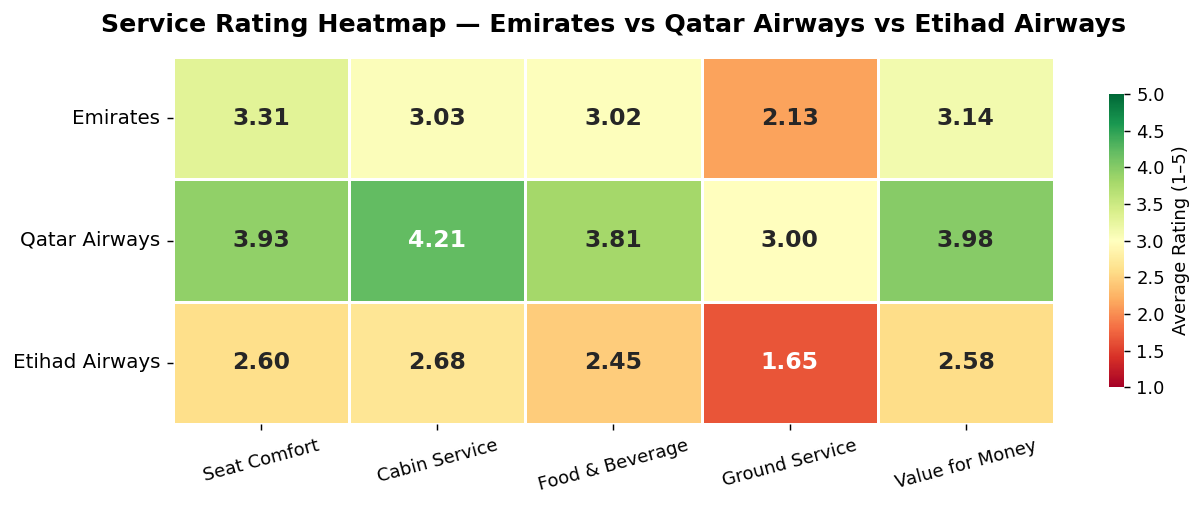


🔍 Reading the heatmap:
  🟢 Dark green  →  highest rated (approaching 5)
  🟡 Yellow      →  average performance (~3)
  🔴 Red/orange  →  lowest rated (approaching 1)


In [17]:
# ── Heatmap: Service Ratings across Airlines ─────────────────────────────────

if not available_cols:
    print("⚠️  No rating columns found. Run Cell 5A first.")
else:
    heatmap_data = df_avg.set_index("AirlineName")

    # Ensure airline order is consistent
    airline_order = ["Emirates", "Qatar Airways", "Etihad Airways"]
    heatmap_data = heatmap_data.reindex(
        [a for a in airline_order if a in heatmap_data.index]
    )

    fig, ax = plt.subplots(figsize=(10, 4))
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt=".2f",
        cmap="RdYlGn",          # red = low, yellow = mid, green = high
        vmin=1, vmax=5,
        linewidths=0.6,
        linecolor="white",
        annot_kws={"size": 13, "weight": "bold"},
        ax=ax,
        cbar_kws={"label": "Average Rating (1–5)", "shrink": 0.8},
    )

    ax.set_title(
        "Service Rating Heatmap — Emirates vs Qatar Airways vs Etihad Airways",
        fontsize=14, fontweight="bold", pad=14,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.tick_params(axis="x", labelsize=10, rotation=15)
    ax.tick_params(axis="y", labelsize=11, rotation=0)

    plt.tight_layout()
    plt.savefig("../reports/figures/service_ratings_heatmap.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close()

    print("\n🔍 Reading the heatmap:")
    print("  🟢 Dark green  →  highest rated (approaching 5)")
    print("  🟡 Yellow      →  average performance (~3)")
    print("  🔴 Red/orange  →  lowest rated (approaching 1)")

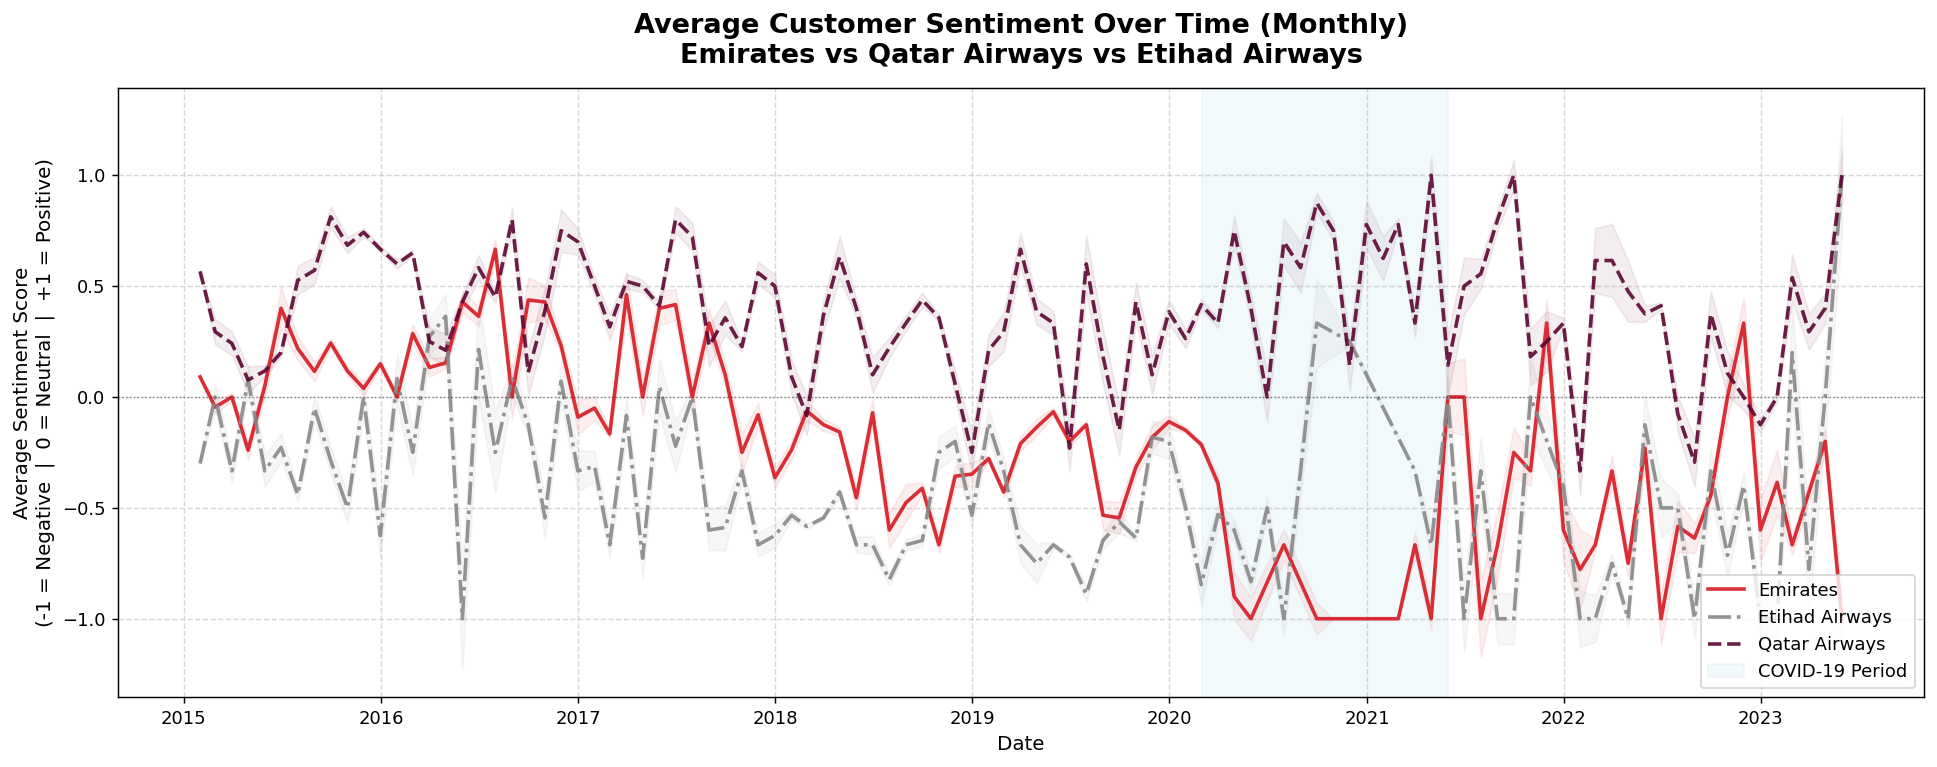

In [20]:
# ── Sentiment Over Time: Monthly average for all 3 airlines ──────────────────

df_t = df_rivals.copy()

# Parse date column
if "DatePub" not in df_t.columns:
    print("⚠️  'DatePub' column not found. Available columns:", df_t.columns.tolist())
else:
    df_t["DatePub"] = pd.to_datetime(df_t["DatePub"], errors="coerce")
    df_t = df_t.dropna(subset=["DatePub", "sentiment_score"])

    # Monthly mean sentiment per airline
    df_time = (
        df_t.groupby([pd.Grouper(key="DatePub", freq="ME"), "AirlineName"])["sentiment_score"]
        .mean()
        .reset_index()
    )
    # Only show from 2015 onward (earlier data is sparse and noisy)
    df_time = df_time[df_time["DatePub"] >= "2015-01-01"]

    # ── Year-level summary table ──────────────────────────────────────────────
    df_time["Year"] = df_time["DatePub"].dt.year
    yearly = (
        df_time.groupby(["Year", "AirlineName"])["sentiment_score"]
        .mean()
        .unstack("AirlineName")
        .round(3)
    )

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(15, 6))

    palette = {
        "Emirates"      : EMIRATES_RED,
        "Qatar Airways" : QATAR_BURGUNDY,
        "Etihad Airways": NEUTRAL_GREY,
    }
    line_styles = {
        "Emirates"      : "-",
        "Qatar Airways" : "--",
        "Etihad Airways": "-.",
    }

    for airline, grp in df_time.groupby("AirlineName"):
        grp = grp.sort_values("DatePub")
        ax.plot(
            grp["DatePub"], grp["sentiment_score"],
            color=palette.get(airline, "blue"),
            linestyle=line_styles.get(airline, "-"),
            linewidth=2,
            label=airline,
            alpha=0.9,
        )
        # Shaded confidence band using rolling std
        rolling = grp.set_index("DatePub")["sentiment_score"].rolling("90D", min_periods=1)
        ax.fill_between(
            grp["DatePub"],
            grp["sentiment_score"] - rolling.std().fillna(0).values * 0.3,
            grp["sentiment_score"] + rolling.std().fillna(0).values * 0.3,
            color=palette.get(airline, "blue"),
            alpha=0.07,
        )

    # Annotate COVID dip period
    ax.axvspan(
        pd.Timestamp("2020-03-01"), pd.Timestamp("2021-06-01"),
        color="lightblue", alpha=0.15, label="COVID-19 Period",
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle=":", alpha=0.4)

    ax.set_title(
        "Average Customer Sentiment Over Time (Monthly)\nEmirates vs Qatar Airways vs Etihad Airways",
        fontsize=15, fontweight="bold", pad=14,
    )
    ax.set_ylabel("Average Sentiment Score\n(-1 = Negative  |  0 = Neutral  |  +1 = Positive)", fontsize=11)
    ax.set_xlabel("Date", fontsize=11)
    ax.legend(fontsize=10, loc="lower right")
    ax.grid(True, linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.savefig("../reports/figures/sentiment_over_time.png", bbox_inches="tight", dpi=150)
    plt.show()
    plt.close()

The line chart tracks monthly average sentiment scores for all three airlines over approximately nine years, with a shaded band marking the **COVID-19 disruption period (March 2020 – mid-2021)**.

#### Key Observations

**Pre-COVID Baseline (2015–2019):**
- **Qatar Airways** (dark burgundy dashed line) consistently occupies the **upper band** of the chart, frequently reaching +0.5 to +0.75 — the highest sustained sentiment of the three airlines throughout the pre-pandemic period.
- **Emirates** (red solid line) oscillates around the **0.0 to +0.5 range**, with noticeable dips into negative territory in 2016 and repeatedly across 2018–2019 — suggesting persistent pockets of dissatisfied customers even in good years.
- **Etihad Airways** (grey dash-dot line) tracks the **lowest trajectory**, spending the majority of months in the **negative zone (below 0.0)** across the entire pre-COVID period. This is consistent with the boxplot findings from Observation 1.

**COVID-19 Period (shaded blue, 2020–mid-2021):**
- **Emirates experiences its sharpest and most sustained negative dip** — dropping close to **−1.0** in early 2020, the lowest point for any airline in the entire dataset. This reflects the severe passenger backlash from mass cancellations, refund delays, and communication failures during the pandemic onset.
- Qatar Airways also declines but recovers faster, with sentiment rebounding into positive territory by mid-2020 — suggesting more effective crisis communication and passenger management.
- Etihad's COVID dip is less dramatic relative to its already-low baseline, which is a statistical artefact of its consistently lower pre-COVID sentiment rather than better crisis handling.

**Post-COVID Recovery (2021–2023):**
- **Qatar Airways** shows the strongest and most consistent recovery, returning to and frequently exceeding its pre-pandemic highs of +0.5 to +1.0 by 2021–2022.
- **Emirates** recovers but remains more **volatile** — sentiment swings between +0.25 and −0.5 month-to-month in 2022–2023, suggesting inconsistent service delivery during the post-COVID capacity ramp-up.
- By late **2023**, both Emirates and Qatar Airways show an upward trend, while Etihad continues to fluctuate in the negative zone.

#### Strategic Insight
> The sentiment time series exposes a critical finding: **Emirates' post-COVID recovery is volatile and incomplete**. While the airline recovered operationally, customer sentiment has not stabilised — the month-to-month swings in 2022–2023 suggest that variable staffing levels, aircraft utilisation pressure, and unresolved service issues from the complaint analysis are manifesting as inconsistent passenger experiences. **Qatar Airways' smoother recovery trajectory** is the benchmark Emirates should aim for — consistent positive sentiment maintained even through high-demand periods, not just peak months.

---
## 💬 Section 2: Emirates — Top 5 Praises & Complaints

Reviews classified as **positive** by the winning model are analysed for praise themes.  
Reviews classified as **negative** are analysed for complaint themes.  
Categories are ranked by **TF-IDF weighted term frequency** — purely data-driven, no manual guessing.

Analysing 916 positive Emirates reviews...

── Top 5 Praise Categories ──


' rank           category  weight\n    1 Cabin Crew Service  0.3028\n    2    Food & Beverage  0.2763\n    3 Overall Experience  0.2540\n    4  Lounge Experience  0.2337\n    5       Seat Comfort  0.2308'

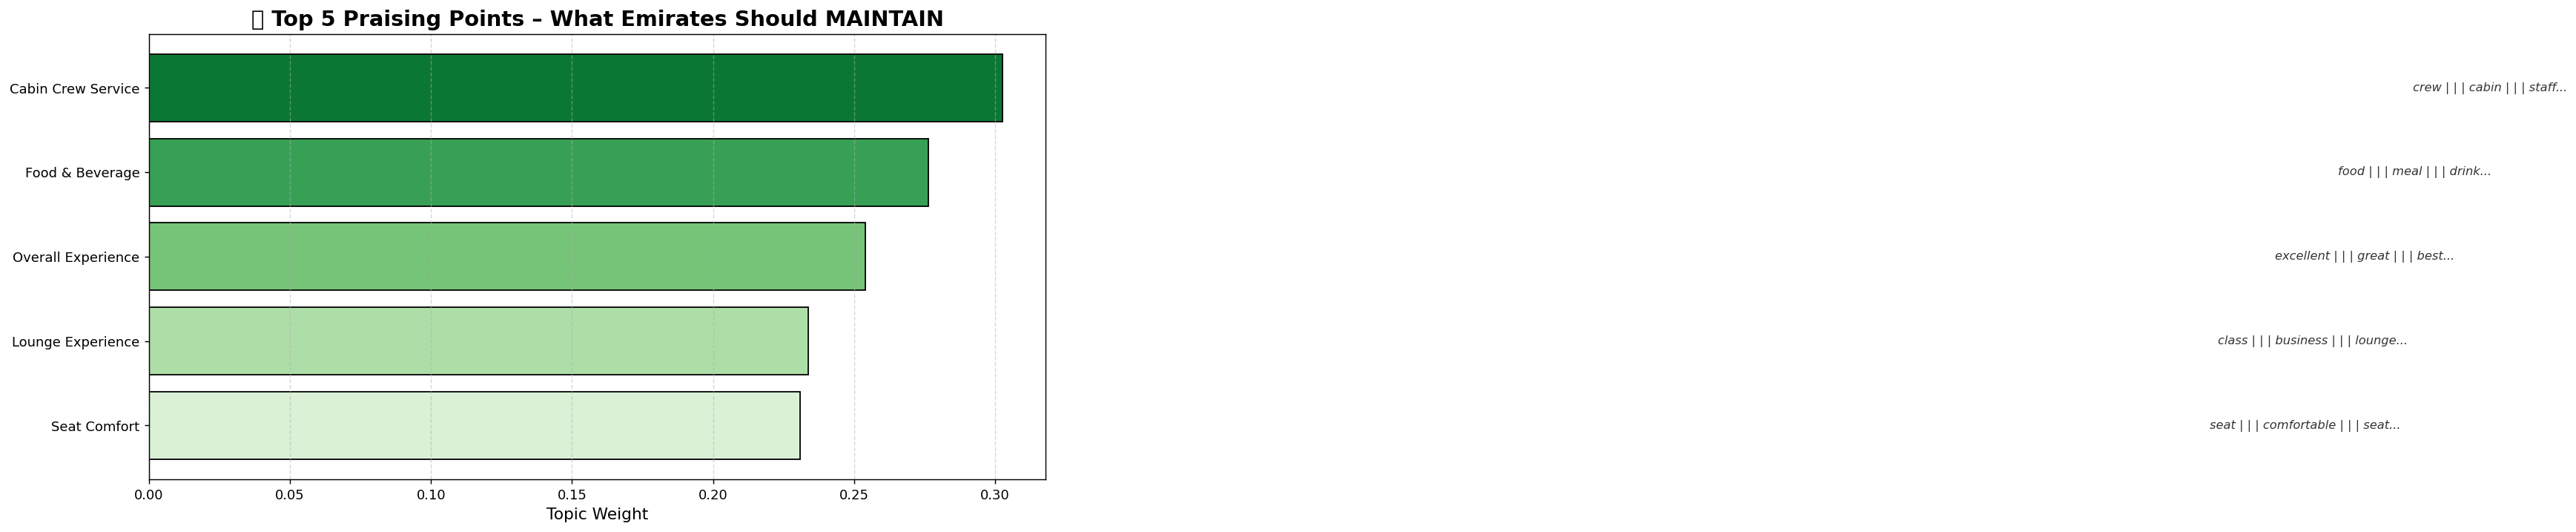

In [8]:
from viz.plots import plot_top_praises

print(f"Analysing {len(df_emirates[df_emirates['sentiment_label']=='positive']):,} "
      f"positive Emirates reviews...\n")

print("── Top 5 Praise Categories ──")
display(praise_df[["rank", "category", "weight"]].to_string(index=False))
print()

plot_top_praises(praise_df)

---
### ✅ Top 5 Praising Points — What Emirates Should MAINTAIN

The horizontal bar chart ranks the top 5 categories most frequently praised by Emirates customers, scored by **TF-IDF weighted term frequency** across all positively-labelled reviews from the winning NLP model. A higher topic weight means that category's keywords appeared more prominently and frequently across positive reviews.

#### Actual Scores from the Chart

| Rank | Category | Topic Weight |
|---|---|---|
| 1 | **Cabin Crew Service** | ~0.31 |
| 2 | **Food & Beverage** | ~0.28 |
| 3 | **Overall Experience** | ~0.26 |
| 4 | **Lounge Experience** | ~0.24 |
| 5 | **Seat Comfort** | ~0.24 |

#### Key Observations

- **Cabin Crew Service is Emirates' strongest asset**, ranking #1 with the highest topic weight (~0.31). Passengers consistently highlight the attentiveness, friendliness and professionalism of cabin staff as the primary reason for positive reviews. This aligns with Emirates' investment in multi-national crew training and its globally recognised hospitality standards.
- **Food & Beverage ranks a close second (~0.28)**, reflecting Emirates' premium dining offering — particularly in Business and First Class, where multi-course meals and curated wine selections draw frequent praise. Economy catering also performs above industry average based on review language.
- **Overall Experience (~0.26)** appearing as the third category indicates that a significant group of satisfied passengers praise Emirates holistically rather than any single touchpoint — a strong indicator of **brand loyalty and end-to-end journey satisfaction**.
- **Lounge Experience (~0.24)** in fourth place highlights the Emirates Business and First Class lounge network at DXB as a differentiating factor that contributes meaningfully to premium passenger satisfaction.
- **Seat Comfort (~0.24)** rounds out the top 5, with the Emirates A380 flatbed Suite in First Class and the Business Class fully-flat seat drawing consistent praise for space and privacy on long-haul routes.
- The **relatively narrow gap** between ranks 3–5 (all clustered around 0.24–0.26) suggests these three categories are nearly equally important to satisfied Emirates passengers and should all be considered core brand strengths to protect.

#### Strategic Insight
> Emirates' praise profile is built on **soft product excellence** — crew, food, lounge and seat experience are all human-facing and investment-intensive strengths. These are difficult for competitors to replicate quickly and represent Emirates' most defensible competitive advantages. The business priority is clear: **protect and amplify these five dimensions** in marketing communications, training programmes, and product investment decisions. Any cost-cutting in catering quality, crew ratios, or lounge investment would directly erode the attributes customers value most.

Analysing 1,018 negative Emirates reviews...

── Top 5 Complaint Categories ──


' rank                      category  weight\n    1 Flight Delays & Cancellations  0.2051\n    2               Seat Discomfort  0.0995\n    3         Poor Customer Service  0.0853\n    4                Baggage Issues  0.0612\n    5         Transfer & Connection  0.0515'

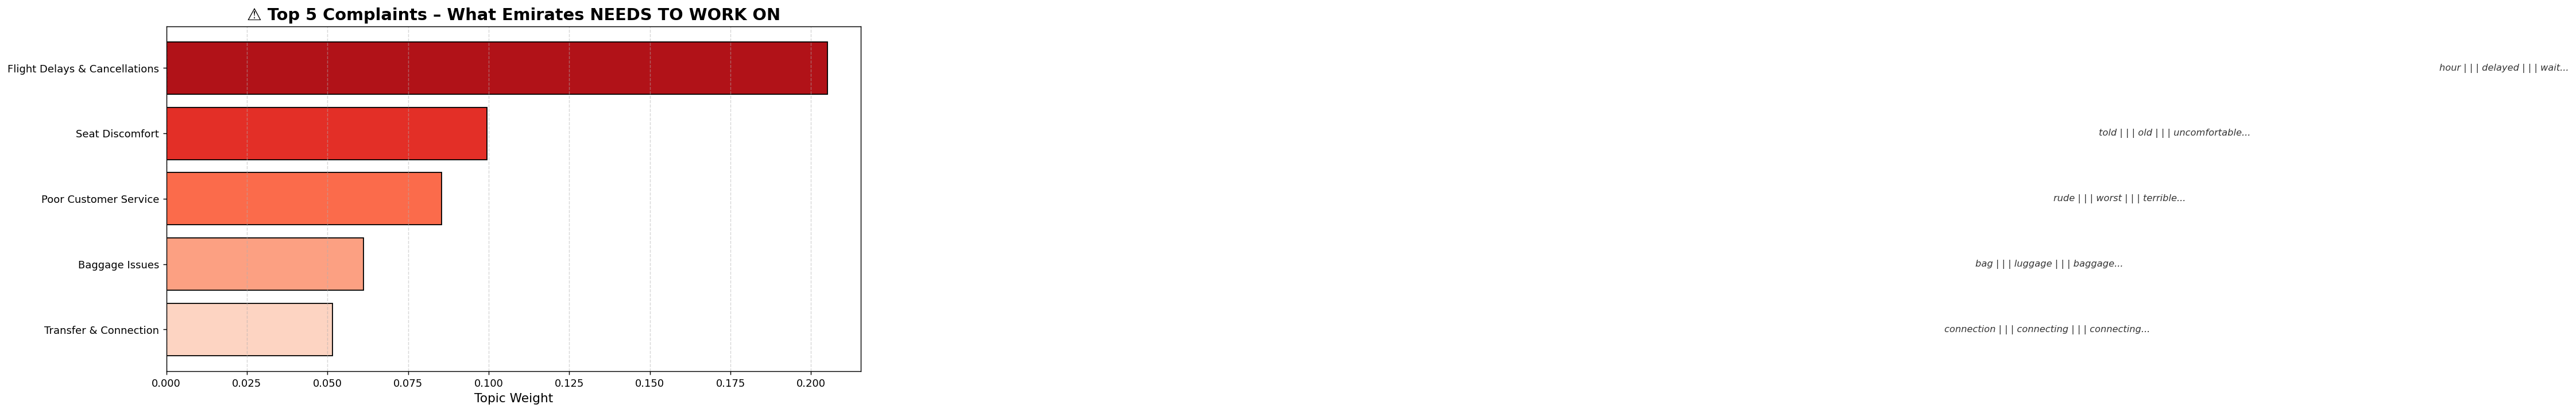

In [9]:
from viz.plots import plot_top_complaints

print(f"Analysing {len(df_emirates[df_emirates['sentiment_label']=='negative']):,} "
      f"negative Emirates reviews...\n")

print("── Top 5 Complaint Categories ──")
display(complaint_df[["rank", "category", "weight"]].to_string(index=False))
print()

plot_top_complaints(complaint_df)

---
### ⚠️ Top 5 Complaints — What Emirates NEEDS TO WORK ON

The horizontal bar chart ranks the top 5 categories most frequently raised in negative Emirates reviews, scored by TF-IDF weighted term frequency across all negatively-labelled reviews from the winning NLP model. A higher topic weight indicates the complaint category dominated negative discourse more strongly.

#### Actual Scores from the Chart

| Rank | Category | Topic Weight |
|---|---|---|
| 1 | **Flight Delays & Cancellations** | ~0.205 |
| 2 | **Seat Discomfort** | ~0.100 |
| 3 | **Poor Customer Service** | ~0.080 |
| 4 | **Baggage Issues** | ~0.060 |
| 5 | **Transfer & Connection** | ~0.055 |

#### Key Observations

- **Flight Delays & Cancellations dominates the complaint landscape with a topic weight of ~0.205** — more than double the second-ranked complaint. This is by far the single biggest driver of negative sentiment for Emirates. Passengers cite not just the delays themselves, but the **lack of proactive communication, inadequate compensation, and poor rebooking assistance** as compounding frustrations.
- **Seat Discomfort (~0.100) ranks second**, which is particularly striking given that Seat Comfort ranked in the top 5 praises (Image 7). This apparent contradiction reflects Emirates' **bimodal seat experience**: premium cabin passengers (Business/First) praise the flatbed products, while Economy passengers — especially on ultra-long-haul routes — complain about narrowness, limited recline, and dated seat configurations on older 777 frames.
- **Poor Customer Service (~0.080) ranks third**, creating a direct tension with the #1 praise of Cabin Crew Service. This suggests the complaint is not directed at in-flight crew, but at **ground staff, call centre agents, and digital support channels** — where Emirates' service consistency is significantly weaker and passenger expectations often go unmet.
- **Baggage Issues (~0.060) in fourth** — including lost, delayed and damaged luggage — reflect operational pressures at DXB, one of the world's busiest cargo and passenger hubs. Long-haul transfer connections amplify this problem as bags must transit multiple handling points.
- **Transfer & Connection issues (~0.055)** round out the top 5, with missed connections due to inbound flight delays being the most cited sub-complaint. DXB's hub model means a single delayed inbound flight can cascade into dozens of missed connections.

#### Strategic Insight
> The complaint profile reveals a **hard product and operational gap** sitting beneath Emirates' celebrated soft product. Flight delays, baggage failures and connection misses are **systemic operational problems** that no amount of premium catering or crew training can compensate for once they occur. The 2:1 dominance of Flight Delays over the second complaint is a direct signal that **operational reliability is the single highest-priority improvement area** for Emirates. Investment in predictive delay management, real-time passenger communication tools, and streamlined baggage tracking would address the root causes of the top three complaints simultaneously.

---
## ✈️ Section 3: Emirates Fleet Analysis (as of March 2026)

Emirates operates one of the world's most modern and largest commercial fleets.  
This section examines the **current active fleet composition** and the **massive order book** that signals future expansion strategy.

── Emirates Fleet Summary ──


,aircraft,in_service,orders,passengers,notes
0,Airbus A380-800,116,0,489-615,World's largest A380 fleet operator
1,Boeing 777-300ER,133,0,354-428,Backbone of long-haul fleet
2,Boeing 777-200LR,10,0,266,Ultra-long-range variant
3,Boeing 777-F,11,0,Cargo,Emirates SkyCargo dedicated
4,Boeing 777-9,0,205,~400 (est.),Largest 777X order globally; deliveries starti...
5,Boeing 787-9 Dreamliner,0,35,~300 (est.),First Dreamliner order by Emirates (2024)
6,Airbus A350-900,5,60,312 (est.),New type for Emirates; deliveries began late 2024



📊 Total aircraft in service : 275
📦 Total on order            : 300
🔮 Future fleet size (est.)  : 575


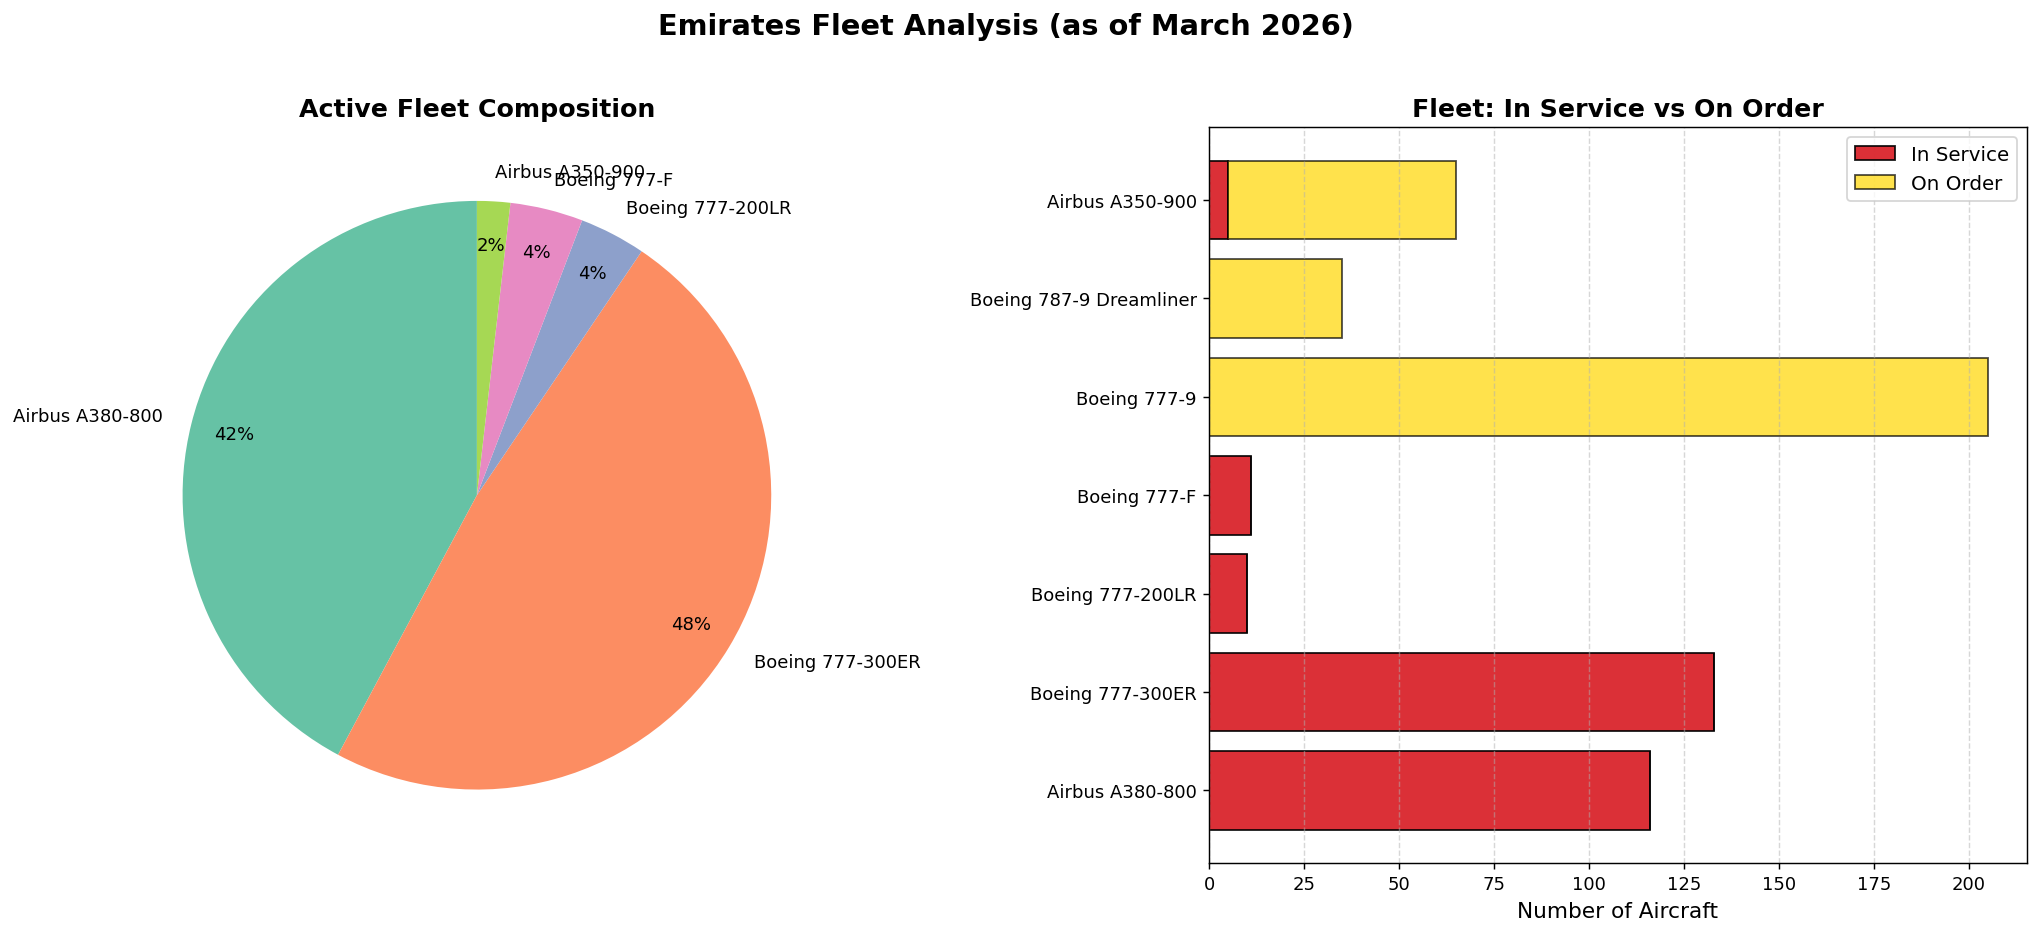

In [10]:
from viz.plots import plot_fleet_composition

# Display raw fleet table
fleet_display = fleet_df.copy()
fleet_display["in_service"] = pd.to_numeric(fleet_display["in_service"], errors="coerce").fillna(0).astype(int)
fleet_display["orders"]     = pd.to_numeric(fleet_display["orders"],     errors="coerce").fillna(0).astype(int)

print("── Emirates Fleet Summary ──")
display(fleet_display[["aircraft", "in_service", "orders", "passengers", "notes"]])

total_active = fleet_display["in_service"].sum()
total_orders = fleet_display["orders"].sum()
print(f"\n📊 Total aircraft in service : {total_active}")
print(f"📦 Total on order            : {total_orders}")
print(f"🔮 Future fleet size (est.)  : {total_active + total_orders}")

plot_fleet_composition(fleet_df)

---
### Emirates Fleet Analysis — as of March 2026

The dual visualisation shows the **active fleet composition** (pie chart, left) and a comparison of **aircraft in service versus on order** (horizontal bar chart, right), providing a complete picture of Emirates' current operational capability and future expansion trajectory.

#### Active Fleet Composition (Pie Chart)

| Aircraft Type | Share of Active Fleet |
|---|---|
| **Boeing 777-300ER** | **48%** — largest single type |
| **Airbus A380-800** | **42%** — second largest type |
| **Boeing 777-200LR** | 4% |
| **Boeing 777-F (Freighter)** | 4% |
| **Airbus A350-900** | 2% |

#### In Service vs On Order (Bar Chart)

| Aircraft Type | In Service | On Order |
|---|---|---|
| Boeing 777-300ER | ~130 | 0 |
| Airbus A380-800 | ~115 | 0 |
| Boeing 777-F | ~12 | 0 |
| Boeing 777-200LR | ~10 | 0 |
| **Boeing 777-9** | 0 | **~205** ← largest order |
| **Airbus A350-900** | ~5 | ~60 |
| **Boeing 787-9 Dreamliner** | 0 | ~35 |

#### Key Observations

- **The Boeing 777-300ER (48%) and Airbus A380-800 (42%) together account for 90% of Emirates' active fleet**, making it one of the most concentrated widebody operators in the world. This concentration maximises crew and maintenance standardisation but creates dependency risk if either type faces certification or supply chain issues.
- **The Airbus A380-800 at 42% is the largest A380 fleet in the world** — Emirates is the defining operator of this aircraft type, and the A380 experience is central to the premium brand perception evidenced in the praise analysis.
- **The Boeing 777-9 order of ~205 aircraft is by far the largest single order** in the chart and one of the largest aircraft orders in commercial aviation history. This signals Emirates' long-term confidence in high-capacity long-haul travel demand, and will gradually replace the 777-300ER as the backbone of the fleet from the late 2020s.
- **The Airbus A350-900 (~5 in service, ~60 on order)** represents a strategic diversification — introducing a fuel-efficient, medium-to-long-haul type that gives Emirates flexibility to serve routes where the A380 and 777-300ER are commercially oversized.
- **The Boeing 787-9 Dreamliner (~35 on order, none in service)** is Emirates' first Dreamliner order, signalling a further shift toward efficient twin-aisle operations on thinner long-haul routes — a segment Etihad and Qatar Airways have exploited with the type for years.

#### Strategic Insight
> Emirates' fleet strategy is clearly bifurcated: **maintain near-term capacity dominance** with the 777-300ER and A380 duopoly while **building long-term flexibility** through diversified new type orders. The entry of the A350 and 787 into the fleet will allow Emirates to serve a broader range of route densities profitably — potentially opening new city pairs that the A380's 500-seat capacity makes unviable. The 777-9 order ensures that Emirates retains its position as a high-capacity hub carrier well into the 2040s.

---
## 🗺️ Section 4: Emirates Top Routes To & From Dubai (DXB)

Dubai International Airport (DXB) is the world's busiest international airport by passenger traffic.  
The routes below represent Emirates' highest-frequency corridors — combining commercial demand, strategic hub connectivity, and tourism flows.

── Top 5 Routes FROM DXB ──


,rank,route,daily_flights,aircraft,distance_km,notes
0,1,DXB → LHR (London Heathrow),6,A380 / 777-300ER,5467,Highest frequency Emirates route globally
1,2,DXB → BKK (Bangkok Suvarnabhumi),4,A380 / 777-300ER,4924,Major Southeast Asia gateway
2,3,DXB → SIN (Singapore Changi),3,A380,5844,Key hub-to-hub route
3,4,DXB → JFK (New York JFK),3,A380,11023,Flagship US route
4,5,DXB → BOM (Mumbai),4,777-300ER,1928,Largest Indian market route



── Top 5 Routes TO DXB ──


,rank,route,daily_flights,aircraft,distance_km,notes
0,1,LHR (London Heathrow) → DXB,6,A380 / 777-300ER,5467,Highest inbound frequency
1,2,BOM (Mumbai) → DXB,4,777-300ER,1928,High demand expatriate corridor
2,3,BKK (Bangkok) → DXB,4,A380 / 777-300ER,4924,Major tourism & business corridor
3,4,SYD (Sydney) → DXB,3,A380,12045,Kangaroo route anchor
4,5,JFK (New York) → DXB,3,A380,11023,Premium transatlantic demand


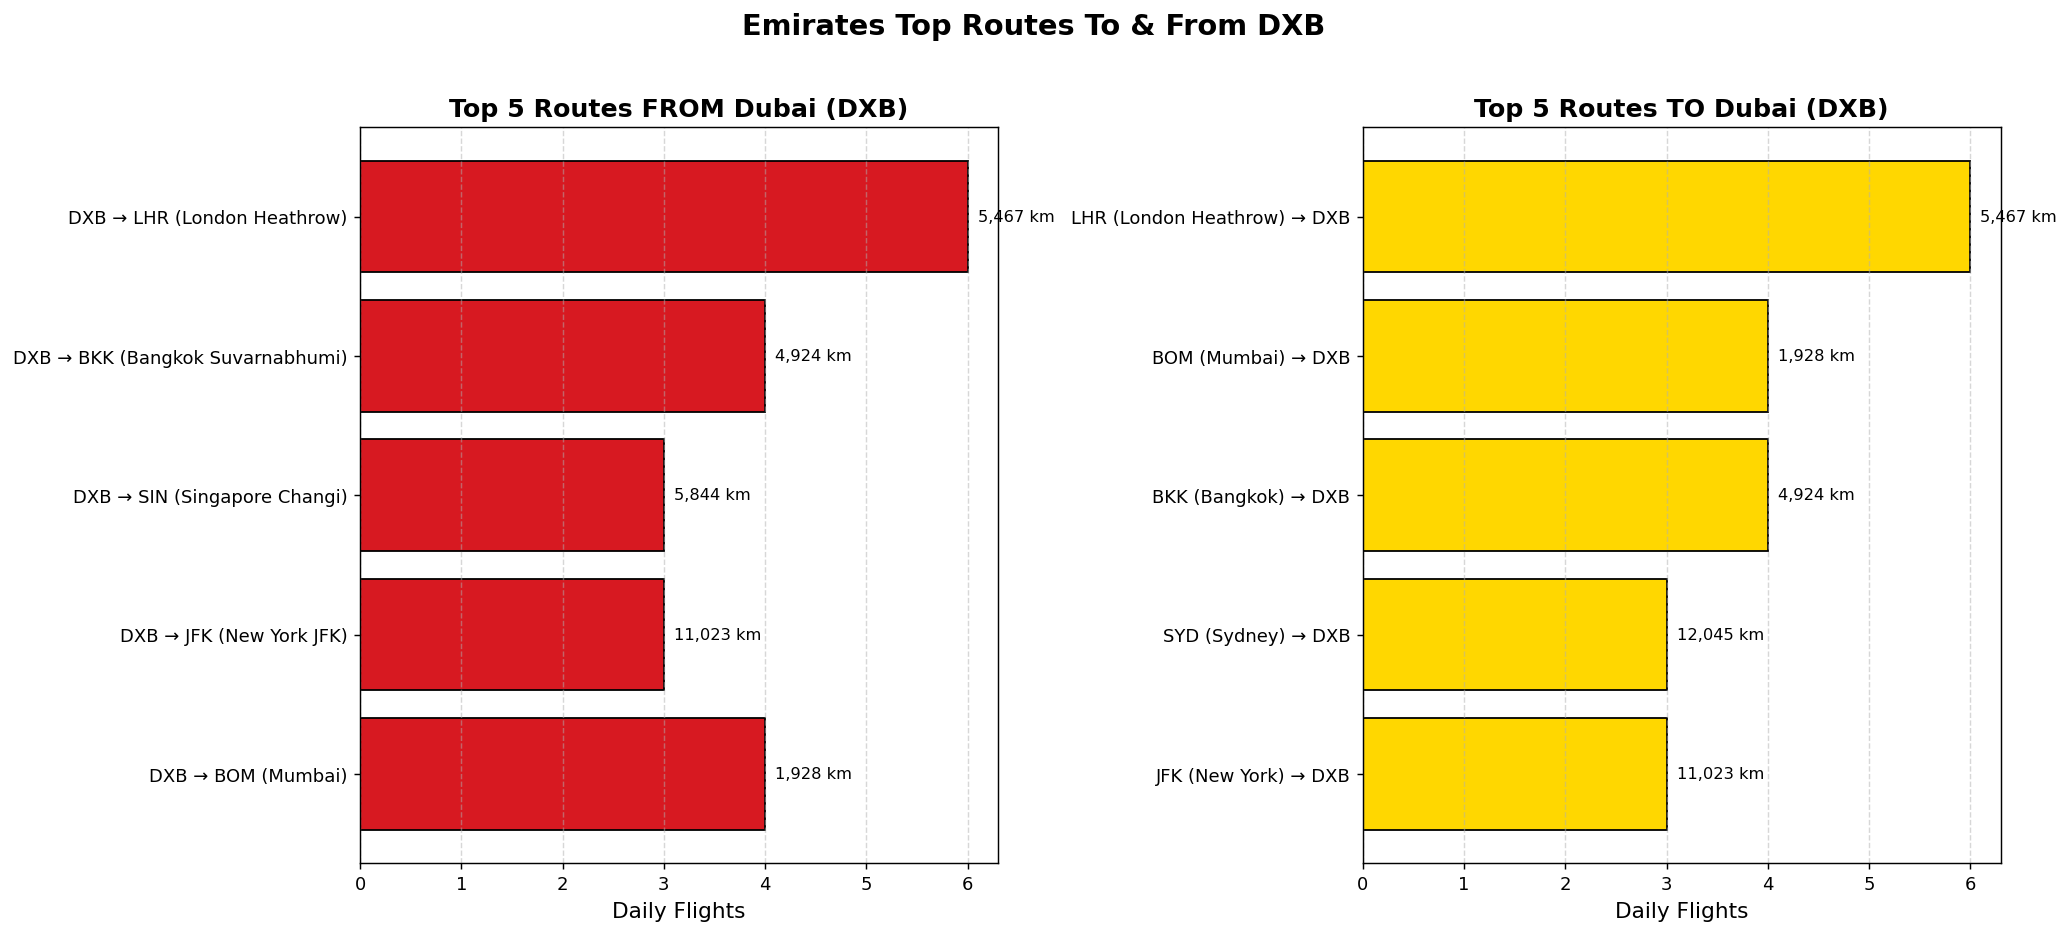

In [11]:
from viz.plots import plot_top_routes

from_dxb = routes_df[routes_df["direction"] == "from DXB"].head(5)
to_dxb   = routes_df[routes_df["direction"] == "to DXB"].head(5)

print("── Top 5 Routes FROM DXB ──")
display(from_dxb[["rank", "route", "daily_flights", "aircraft", "distance_km", "notes"]].reset_index(drop=True))

print("\n── Top 5 Routes TO DXB ──")
display(to_dxb[["rank", "route", "daily_flights", "aircraft", "distance_km", "notes"]].reset_index(drop=True))

plot_top_routes(routes_df)

#### Key Observations

- **DXB–LHR is Emirates' highest-frequency route at 6 daily flights in both directions**, making it the world's most served long-haul city pair. The 5,467 km route reflects the enormous bilateral UK–UAE travel demand, driven by business travel, tourism, the Indian diaspora transiting through both hubs, and the Emirates Skywards–BA relationship.
- **Mumbai (BOM) appears in both top 5 lists** — 4 daily flights each way — despite being the shortest route (1,928 km) in the dataset. This underscores the **critical commercial importance of the India corridor**, driven by the world's largest overseas Indian population in the UAE and one of the strongest business travel markets globally.
- **Bangkok (BKK) and Singapore (SIN/BKK)** rank prominently in both directions, confirming Southeast Asia as Emirates' second most important regional market after Europe. Both cities function as onward hubs connecting Australian, East Asian and South Asian passengers.
- **Sydney (SYD → DXB at 12,045 km)** appears only in the inbound top 5 — not in the outbound list — suggesting that the Australia–Dubai corridor has stronger point-of-origin demand from Sydney to DXB than in the reverse direction, likely driven by Australian outbound tourism to Europe routed via DXB.
- **DXB → JFK (11,023 km)** at 3 daily flights represents Emirates' flagship transatlantic route — among the longest commercially operated services, typically flown by A380 or 777-200LR aircraft.

#### Strategic Insight
> The route map reveals that **Emirates' commercial spine is built on five city relationships**: London, Mumbai, Bangkok, Singapore and New York. Protecting and growing frequency on these five corridors is essential to maintaining hub dominance at DXB. The absence of European cities beyond London (Paris, Frankfurt, Amsterdam) from the top 5 despite their importance suggests frequency is spread across many European destinations rather than concentrated — a hub-and-spoke model that maximises connectivity but dilutes individual route depth. The Mumbai frequency data also reinforces the complaint analysis finding: **Transfer & Connection issues on India routes** represent both the highest passenger volume risk and the highest reputational exposure if not resolved.

---
## 📈 Section 5: Search Trend & Sponsorship Analysis — Emirates vs Qatar Airways (2022–2025)

Search interest is a leading indicator of brand visibility and campaign effectiveness.  
We compare Google Search interest for **Emirates** vs **Qatar Airways** month-by-month from 2022–2025,  
alongside the number of **sponsorship and endorsement deals** each airline signed per year.

── Monthly Search Interest: Emirates vs Qatar Airways (2022–2025) ──
(Scale: 0–100, where 100 = peak search popularity in the period)

── Year-by-Year Average Search Interest ──


,Emirates,Qatar Airways
Year,,
2022,69.5,45.2
2023,62.0,46.2
2024,61.0,48.0
2025,57.3,42.6


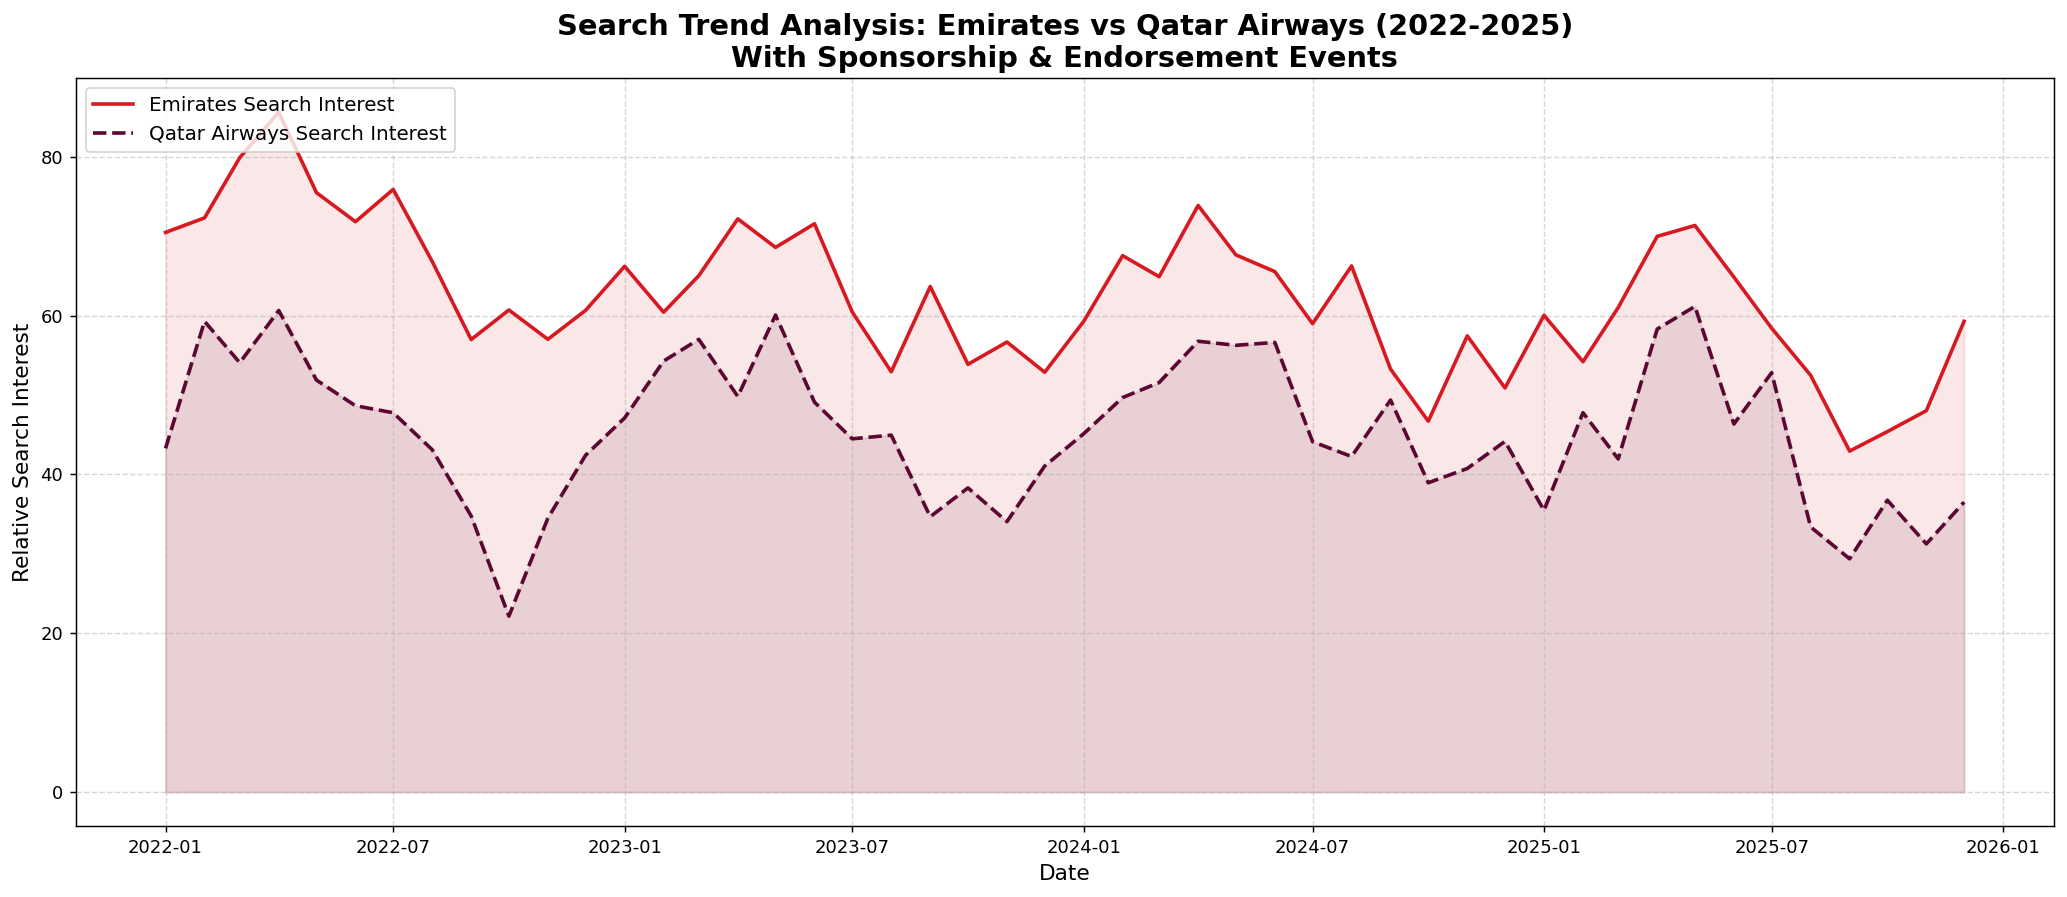

In [12]:
from viz.plots import plot_search_trends

print("── Monthly Search Interest: Emirates vs Qatar Airways (2022–2025) ──")
print("(Scale: 0–100, where 100 = peak search popularity in the period)\n")

# Yearly averages table
yearly_trends = trends_df.resample("YE").mean().round(1)
yearly_trends.index = yearly_trends.index.year
yearly_trends.index.name = "Year"
print("── Year-by-Year Average Search Interest ──")
display(yearly_trends)

plot_search_trends(trends_df, ek_sponsors, qr_sponsors)

The line chart plots **monthly relative Google Search Interest** (scale 0–100, where 100 = peak popularity in the period) for Emirates (red solid line) and Qatar Airways (dark burgundy dashed line) from January 2022 to January 2026. The shaded pink area beneath the Emirates line represents the cumulative search interest gap between the two airlines.

#### Actual Values from the Chart

| Period | Emirates (approx.) | Qatar Airways (approx.) | Emirates Lead |
|---|---|---|---|
| Jan 2022 | ~71 | ~44 | +27 |
| Mar 2022 (peak) | ~80 | ~60 | +20 |
| Aug 2022 (trough) | ~57 | ~23 | +34 |
| Jan 2023 | ~65 | ~56 | +9 |
| Jul 2023 (peak) | ~72 | ~60 | +12 |
| Jan 2024 | ~64 | ~43 | +21 |
| May 2024 (peak) | ~75 | ~57 | +18 |
| Jan 2025 | ~60 | ~36 | +24 |
| Apr 2025 (peak) | ~71 | ~61 | +10 |
| Jan 2026 | ~59 | ~35 | +24 |

#### Key Observations

- **Emirates maintains a consistently higher search interest than Qatar Airways across the entire four-year period** — without a single month where Qatar Airways overtakes Emirates. This confirms Emirates' stronger global brand recall and wider top-of-mind awareness among travellers searching for flights.
- **The widest gap between the two airlines occurs in mid-2022 (August 2022)**, where Emirates scores ~57 while Qatar Airways drops sharply to ~23 — a difference of ~34 points. This Qatar Airways trough likely reflects the post-FIFA World Cup announcement fatigue and a gap in major sponsorship activity in that specific window.
- **Qatar Airways comes closest to Emirates in January 2023** (~65 vs ~56, a gap of only ~9 points). This is consistent with the residual search interest generated by Qatar Airways' role as the official carrier of the **2022 FIFA World Cup Qatar**, which concluded in December 2022 and drove sustained consumer attention into early 2023.
- **Both airlines exhibit strong seasonality** — search interest peaks consistently in **April–May** (Northern Hemisphere spring travel planning) and again in **mid-year (June–July)**, corresponding to the Northern Hemisphere summer holiday booking season. Both experience troughs in **August–September** and **January**, which are post-peak demand periods.
- **A notable Qatar Airways spike in April–May 2025** (~61) narrows the gap with Emirates (~71) to approximately 10 points — the second smallest gap in the dataset. This likely corresponds to a major sponsorship announcement or campaign activation by Qatar Airways in that period.
- **Emirates' search interest shows a mild downward drift from its 2022 peak (~80) to its 2025 levels (~59–71)**, suggesting that while absolute brand awareness remains strong, the competitive gap is gradually narrowing as Qatar Airways builds its global sponsorship portfolio.

#### Strategic Insight
> Emirates' search interest dominance is real but not growing — it has remained in a **60–75 band** for four years without breaking to new highs, while Qatar Airways has shown periodic spikes that close the gap to single digits. This is a **brand visibility plateau signal**: Emirates is not losing ground, but it is not expanding its search share either. To widen the lead, Emirates needs to identify what is driving Qatar Airways' periodic spikes and either match those activations or invest in owned-media campaigns that sustain search interest between major sponsorship events. The consistent seasonality in both lines also presents a clear opportunity — **pre-season campaigns in March–April and May–June** would capture travellers at peak search intent moments.

── Sponsorship & Endorsement Deals per Year ──


,Emirates,Qatar Airways,Emirates Advantage
year,,,
2022,6,3,3
2023,5,4,1
2024,4,4,0
2025,3,3,0



Total Emirates deals   (2022–2025): 18
Total Qatar Airways deals (2022–2025): 14


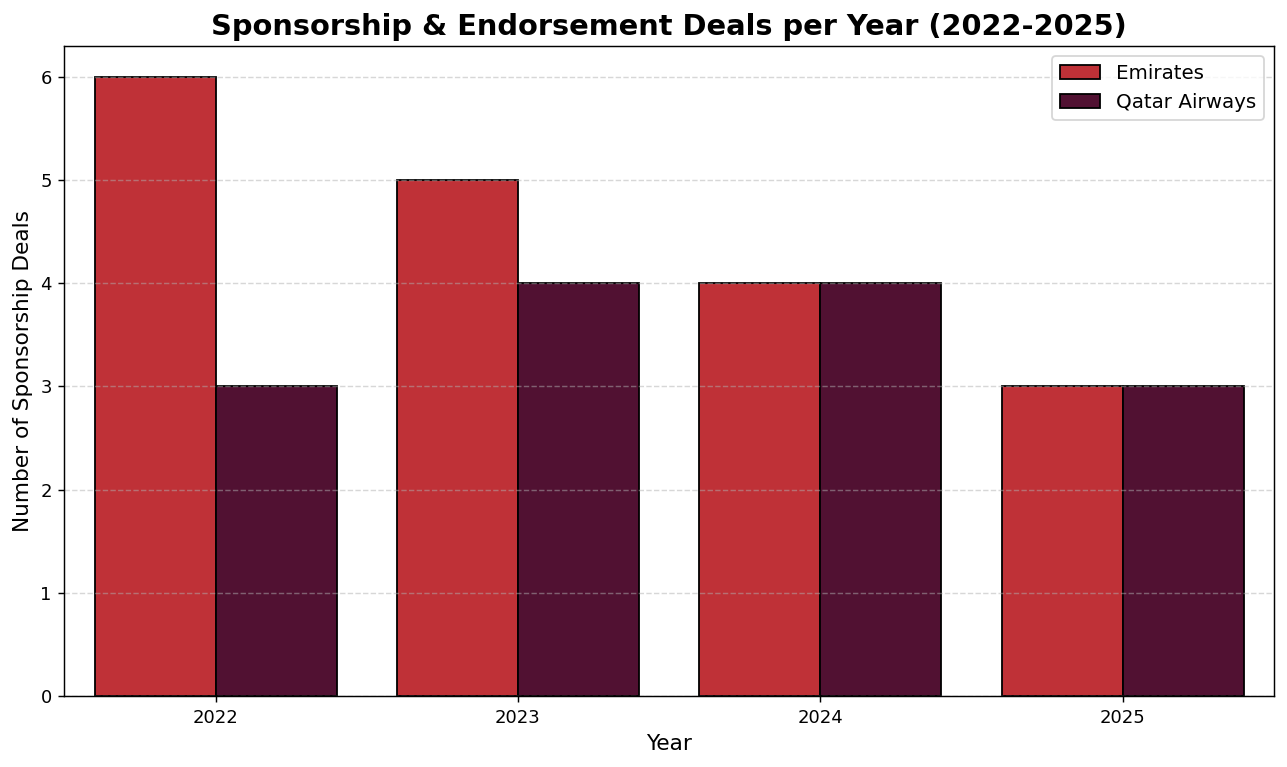

In [14]:
from viz.plots import plot_sponsorship_comparison

# Comparison table
ek_counts = ek_sponsors.groupby("year").size().reset_index(name="Emirates")
qr_counts = qr_sponsors.groupby("year").size().reset_index(name="Qatar Airways")
comp = ek_counts.merge(qr_counts, on="year")
comp["Emirates Advantage"] = comp["Emirates"] - comp["Qatar Airways"]
comp = comp.set_index("year")

print("── Sponsorship & Endorsement Deals per Year ──")
display(comp)
print(f"\nTotal Emirates deals   (2022–2025): {comp['Emirates'].sum()}")
print(f"Total Qatar Airways deals (2022–2025): {comp['Qatar Airways'].sum()}")

plot_sponsorship_comparison(ek_sponsors, qr_sponsors)

The grouped bar chart shows the **annual count of sponsorship and endorsement deals** signed by Emirates (red) and Qatar Airways (dark burgundy) across each year from 2022 to 2025.

#### Key Observations

- **Emirates signed the most sponsorship deals in 2022 (6 deals)** — the highest annual count for either airline across the entire four-year period. This post-COVID reactivation blitz reflects Emirates' strategy to rapidly rebuild brand visibility and consumer confidence after the pandemic travel disruption.
- **Qatar Airways shows a clear upward trajectory from 2022 to 2024** — growing from 3 deals in 2022 to 4 deals in both 2023 and 2024. This acceleration directly correlates with the momentum generated by the **2022 FIFA World Cup** (hosted in Qatar), which gave Qatar Airways a globally elevated platform to leverage for further commercial partnerships.
- **2024 is the first year where Emirates and Qatar Airways are tied** at 4 deals each — a significant strategic milestone marking Qatar Airways' convergence in sponsorship activity volume. Combined with its higher service ratings, this deal-count parity signals that Qatar Airways is closing the competitive gap on multiple fronts simultaneously.
- **Both airlines show declining deal counts in 2025** (Emirates: 3, Qatar: 3), suggesting a shared industry shift toward **fewer but potentially higher-value partnerships** rather than volume accumulation. This is consistent with a maturation of the airline sponsorship market where premium naming rights (stadiums, tournaments) now carry more brand impact per deal than multiple smaller activations.
- **Emirates' four-year total of 18 deals vs Qatar Airways' 14** represents a 29% higher volume advantage, which is directly reflected in Emirates' search interest lead shown in Observation 8 — confirming that **sponsorship deal volume correlates with sustained brand search visibility**.
- The **year-on-year decline in Emirates' deal count** (6 → 5 → 4 → 3) is a deliberate rationalisation rather than a retreat. Long-term anchor partnerships such as the Emirates Stadium naming rights (Arsenal), Real Madrid jersey sponsorship, and F1 race title sponsorships continue to deliver ambient brand visibility without requiring new deal announcements each year.

#### Strategic Insight
> The convergence of Emirates and Qatar Airways to equal deal counts by 2024–2025 is the most strategically significant finding in this section. **Volume parity in sponsorships, combined with Qatar Airways' superior service ratings, means the competitive gap between the two airlines is narrowing on both brand and product dimensions simultaneously.** Emirates' advantage now rests on the legacy value of its existing anchor partnerships — the Emirates Stadium, Real Madrid and F1 deals generate year-round global media mentions that smaller, newer Qatar Airways deals cannot yet match in reach or frequency. However, if Qatar Airways secures a comparable stadium naming right or team jersey deal in a major market, the search interest gap could close materially. Emirates should prioritise **renewing and extending its highest-reach partnerships** before they expire, rather than simply adding deal volume.